In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, root_mean_squared_error, r2_score
import warnings
import xgboost
from xgboost import XGBRegressor

# Dataset: Bicicletas alugadas em Seoul 

Quantidade de bicicletas alugadas em Seoul, na Coreia do Sul, entre 2017 e 2018.

In [2]:
df = pd.read_excel("seoul_bike_data.xlsx", engine='openpyxl')
df.head()

,DateTime,Day,Weekday,Hour,Rented Bike Count,Temperature(°C),Humidity(%),Wind speed (m/s),Visibility (10m),Dew point temperature(°C),Solar Radiation (MJ/m2),Rainfall(mm),Snowfall (cm)
0,2017-01-12 00:00:00,12,5,0,254,-5.2,37,2.2,2000,-17.6,0.0,0.0,0.0
1,2017-01-12 01:00:00,12,5,1,204,-5.5,38,0.8,2000,-17.6,0.0,0.0,0.0
2,2017-01-12 02:00:00,12,5,2,173,-6.0,39,1.0,2000,-17.7,0.0,0.0,0.0
3,2017-01-12 03:00:00,12,5,3,107,-6.2,40,0.9,2000,-17.6,0.0,0.0,0.0
4,2017-01-12 04:00:00,12,5,4,78,-6.0,36,2.3,2000,-18.6,0.0,0.0,0.0


## Renomeando as colunas e verificando dados estatísticos:

In [3]:
renome_colunas = {
    'DateTime': 'Data e hora',
    'Day': 'Dia',
    'Weekday': 'Dia da semana',
    'Hour': 'Hora',
    'Rented Bike Count': 'Bicicletas alugadas',
    'Temperature(°C)': 'Temperatura(°C)',
    'Humidity(%)': 'Humidade(%)',
    'Wind speed (m/s)': 'Velocidade do vento(m/s)',
    'Visibility (10m)': 'Visibilidade(10m)',
    'Dew point temperature(°C)': 'Ponto de orvalho(°C)',
    'Solar Radiation (MJ/m2)': 'Radiação solar(MJ/m2)',
    'Rainfall(mm)': 'Chuva(mm)',
    'Snowfall (cm)': 'Neve(cm)'
}

df = df.rename(columns=renome_colunas)
df.describe()

,Dia,Dia da semana,Hora,Bicicletas alugadas,Temperatura(°C),Humidade(%),Velocidade do vento(m/s),Visibilidade(10m),Ponto de orvalho(°C),Radiação solar(MJ/m2),Chuva(mm),Neve(cm)
count,8760.000000,8760.000000,8760.000000,8760.000000,8760.000000,8760.000000,8760.000000,8760.000000,8760.000000,8760.000000,8760.000000,8760.000000
mean,15.720548,3.980822,11.500000,704.602055,12.882922,58.226256,1.724909,1436.825799,4.073813,0.569111,0.148687,0.075068
std,8.796749,2.004811,6.922582,644.997468,11.944825,20.362413,1.036300,608.298712,13.060369,0.868746,1.128193,0.436746
min,1.000000,1.000000,0.000000,0.000000,-17.800000,0.000000,0.000000,27.000000,-30.600000,0.000000,0.000000,0.000000
25%,8.000000,2.000000,5.750000,191.000000,3.500000,42.000000,0.900000,940.000000,-4.700000,0.000000,0.000000,0.000000
50%,16.000000,4.000000,11.500000,504.500000,13.700000,57.000000,1.500000,1698.000000,5.100000,0.010000,0.000000,0.000000
75%,23.000000,6.000000,17.250000,1065.250000,22.500000,74.000000,2.300000,2000.000000,14.800000,0.930000,0.000000,0.000000
max,31.000000,7.000000,23.000000,3556.000000,39.400000,98.000000,7.400000,2000.000000,27.200000,3.520000,35.000000,8.800000


## Dias da Semana vs Bicicletas Alugadas:

1-Domingo<br>
2-Segunda<br>
3-Terça<br>
4-Quarta<br>
5-Quinta<br>
6-Sexta<br>
7-Sábado

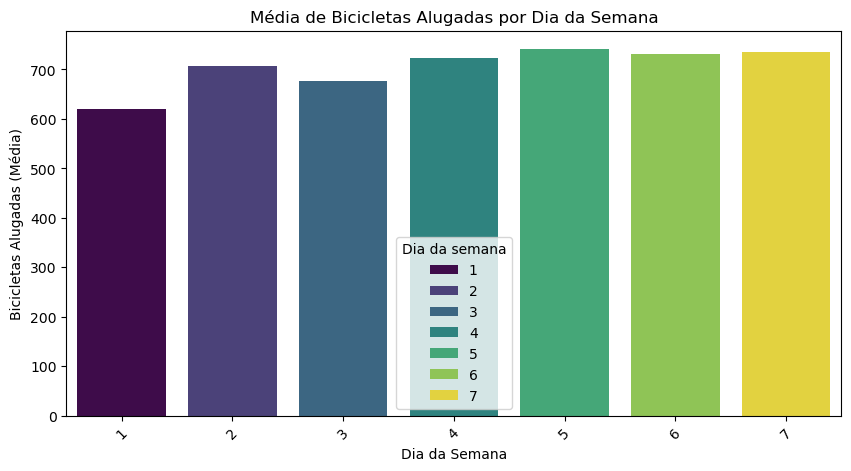

In [4]:
bikes_por_dia = df.groupby('Dia da semana')['Bicicletas alugadas'].mean().reset_index()

plt.figure(figsize=(10, 5))
sns.barplot(x='Dia da semana', y='Bicicletas alugadas', hue='Dia da semana', data=bikes_por_dia, palette='viridis')
plt.title('Média de Bicicletas Alugadas por Dia da Semana')
plt.xlabel('Dia da Semana')
plt.ylabel('Bicicletas Alugadas (Média)')
plt.xticks(rotation=45)
plt.show()

## Aplicando a técnica de seleção de atributos.

Prever a quantidade de bicicletas que serão alugadas a partir de fatores como: dias da semana e condições climáticas.

In [5]:

df_selecao = df.iloc[:, [1, 2, 3, 4, 5, 7, 11, 12]] 
df_selecao.head()

,Dia,Dia da semana,Hora,Bicicletas alugadas,Temperatura(°C),Velocidade do vento(m/s),Chuva(mm),Neve(cm)
0,12,5,0,254,-5.2,2.2,0.0,0.0
1,12,5,1,204,-5.5,0.8,0.0,0.0
2,12,5,2,173,-6.0,1.0,0.0,0.0
3,12,5,3,107,-6.2,0.9,0.0,0.0
4,12,5,4,78,-6.0,2.3,0.0,0.0


## Correlação entre Variáveis (colunas):

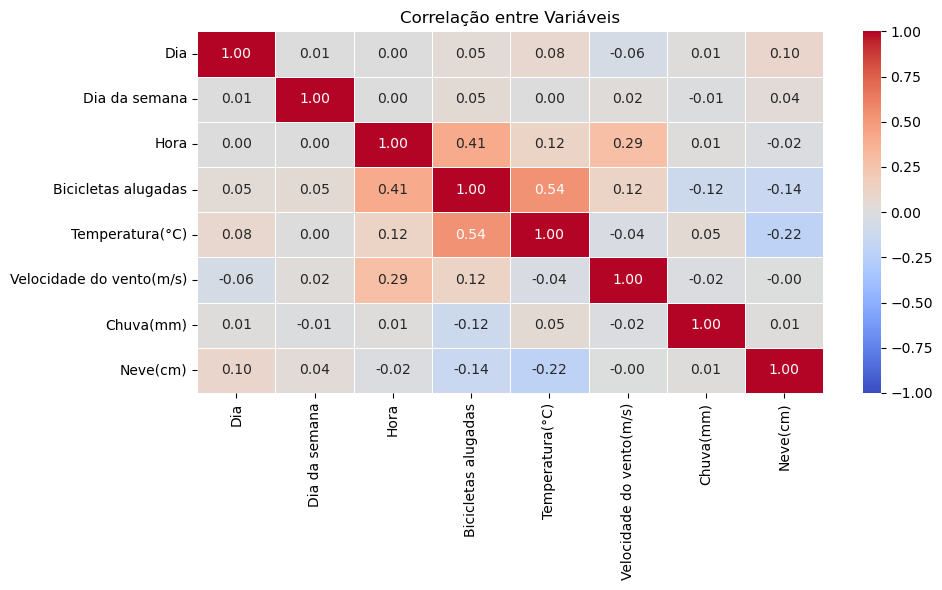

In [6]:
colunas = ['Dia', 'Dia da semana', 'Hora', 'Bicicletas alugadas', 'Temperatura(°C)', 'Velocidade do vento(m/s)', 'Chuva(mm)', 'Neve(cm)']

df_novo = df[colunas]
corr = df_novo.corr()

plt.figure(figsize=(10, 6))
sns.heatmap(corr, annot=True, cmap='coolwarm', vmin=-1, vmax=1, fmt=".2f",
            linewidths=0.5, linecolor='white')
plt.title('Correlação entre Variáveis')
plt.tight_layout()
plt.show()

Bicicletas Alugadas vs Temperatura (0.54): Dias mais quentes têm maior demanda por bicicletas.

Bicicletas Alugadas vs Chuva(mm) (-0.12): Dias mais chuvosos tendem a ter menos aluguéis.

Bicicletas Alugadas vs Neve(cm) (-0.14): Dias com neve tendem a ter menos aluguéis.


## Tipo de Problema: Regressão

O problema é de **regressão**, pois pretende **prever o número de bicicletas alugadas** com base nos dias da semana (temporais) e nas condições climáticas (meteorológicas).

O modelo de regressão foi implementado usando XGBoost.

## Divisão e Treinamento:

In [7]:
colunas = ['Dia da semana', 'Hora', 'Temperatura(°C)', 'Chuva(mm)', 'Neve(cm)'] 
X = df[colunas]
y = df['Bicicletas alugadas'] 

df = df[df['Bicicletas alugadas'] <= 1500]

X_treino, X_teste, y_treino, y_teste = train_test_split(X, y, test_size=0.25, random_state=42)

modelo = XGBRegressor(n_estimators=200, learning_rate=0.05)
modelo.fit(X_treino, y_treino)

y_previsao = modelo.predict(X_teste)

print("Colunas do modelo de previsão:", modelo.feature_names_in_)


Colunas do modelo de previsão: ['Dia da semana' 'Hora' 'Temperatura(°C)' 'Chuva(mm)' 'Neve(cm)']


## Previsões:

**1 - Prever a quantidade de bicicletas alugadas para um domingo às 13h, com 25 ºC e sem chuva.**

In [8]:
novos_dados = pd.DataFrame({         
    'Dia da semana': [1],       
    'Hora': [13], 
    'Temperatura(°C)': [25],       
    'Chuva(mm)': [0],           
    'Neve(cm)': [0],            
})

previsao = modelo.predict(novos_dados)

print(f"Previsão de bicicletas alugadas: {int(previsao[0])} unidades")

Previsão de bicicletas alugadas: 1164 unidades


**2 - Prever a quantidade de bicicletas alugadas para um domingo às 13h, com 25 ºC e com chuva.**

In [9]:
novos_dados = pd.DataFrame({         
    'Dia da semana': [1],       
    'Hora': [13], 
    'Temperatura(°C)': [25],       
    'Chuva(mm)': [1],           
    'Neve(cm)': [0],            
})

previsao = modelo.predict(novos_dados)

print(f"Previsão de bicicletas alugadas: {int(previsao[0])} unidades")

Previsão de bicicletas alugadas: 422 unidades


**3 - Prever a quantidade de bicicletas alugadas para uma quinta às 7h, com -4 ºC e com neve.**

In [ ]:
novos_dados = pd.DataFrame({         
    'Dia da semana': [5],       
    'Hora': [7], 
    'Temperatura(°C)': [-4],       
    'Chuva(mm)': [0],           
    'Neve(cm)': [1],            
})

previsao = modelo.predict(novos_dados)

print(f"Previsão de bicicletas alugadas: {int(previsao[0])} unidades")